<center><img src = "https://github.com/Trading-com-Dados/pmf/blob/main/logotipo-trading-com-dados.svg?raw=true" width = "200">

<center><img src = "https://github.com/Trading-com-Dados/pmf/blob/main/PMF%20002.png?raw=true" width = "700">

# Estatística no Mercado Financeiro

Introdução


<img src="https://img.ifunny.co/images/d2e5651b80064003b248c3175ac092d94dd8dafe6b6375e441e1543c1e90ad7e_1.webp" width="500" align="left"/>

Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

from scipy import stats
import pylab
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os

import yfinance as yf

import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import sweetviz as sv

In [2]:
import numpy as np
from scipy import stats
import plotly.express as px

np.random.seed(13)
a = np.random.randint(50, size = 30)
b = np.random.randint(50, size = 30)
ab = zip(a,b)
fig = px.scatter(ab, x=a, y=b, template='simple_white', width=400, height=400)
fig.update_layout(paper_bgcolor="#f7f8fa", margin=dict(l=20, r=20, t=20, b=20))

# 2. Análises exploratórias de dados: EDA

Estatística Descritiva

O primeiro passo ao se analisar qualquer conjunto de dados, é entender como eles estão distribuídos.

Não é à toa que a primeira visualização que fizemos neste módulo foi um **scatter plot** (gráfico de dispersão)

# 2.1 Distribuição dos dados

Medidas de posição e dispersão

Distribuição dos dados é o ponto chave para praticamente tudo o que entendemos por estatística.

Apesar disso, muitas vezes é simplesmente ignorada nos modelos. Muitas vezes, modelos podem não funcionar por causa de algumas poucas observações que distorcem a distribuição dos dados.

# 2.1.1 Distribuição Normal

Medidas paramétricas (média, desvios, intervalos de confiança, coeficiente de variação) funcionam bem

A distribuição normal (também chamada de Gaussiana), possui esse formato de 'sino'

A maioria dos fenômenos observados possuem distribuição normal

C:\Users\akira\AppData\Local\Temp\ipykernel_6608\101072020.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




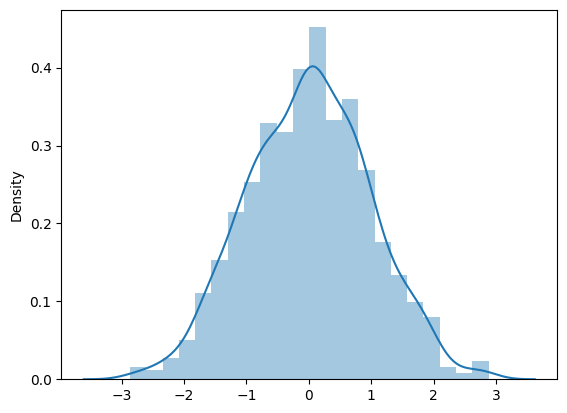

In [3]:
normal_dist = np.random.normal(0,1,1000)
normal_fig01 =sns.distplot(normal_dist, hist = True, kde = True)

Uma das propriedades mais importantes da distribuição normal é que a média, mediana e moda serão iguais.

É difícil verificar uma distribuição que seja exatamente normal, portanto estes valores serão próximos.

Medidas de posição: média, mediana e moda

**Média:**

A média é a média aritmética de um conjunto de números.

**Mediana:**

A mediana é um valor numérico que separa a metade superior de um conjunto da metade inferior.

**Moda:**

Valor que acontece com mais frequência.

In [4]:
print(np.mean(normal_dist))
print(np.median(normal_dist))
print(stats.mode(normal_dist))

0.0017066272520296834
0.0239444097099838
ModeResult(mode=-2.8662660210883883, count=1)


In [5]:
#Arrendodamento>
print(round(np.mean(normal_dist), 2))
print(round(np.median(normal_dist), 2))

0.0
0.02


Visualizar no plotly

In [6]:
fig01 = px.histogram(normal_dist, color_discrete_sequence=['lightseagreen'])
fig01.add_vline(x=np.mean(normal_dist), line_width=3,  line_color="red")
fig01.add_vline(x=np.median(normal_dist), line_width=3, line_dash="dash", line_color="red")
fig01.update_layout(width=400, height=400, template = 'simple_white',
                    paper_bgcolor="#f7f8fa", margin=dict(l=20, r=20, t=20, b=20),
                    showlegend=False)

Como saber se uma distribuição é normal?

Para isso, estudaremos os métodos a seguir.

Testes de normalidade (caindo em desuso)

À medida que aumenta o uso de grandes volumes de dados, os testes de normalidade vão caindo em desuso, pois eles são sensíveis justamente à quantidade de dados.

Para uma verificação da queda da normalidade com o volume de dados, acompanhe este breve teste que desenvolvemos:

https://colab.research.google.com/drive/1CVk9bKoV1Ld8WZpFYOkbsPDru1ZPQuPk?usp=sharing

# Medidas de posição: Quantis

Quantis são pontos de corte que dividem um intervalo de distribuição de probabilidade em intervalos contínuos com probabilidades iguais, ou as observações de uma amostra do mesmo jeito.

<img src="https://cdn.scribbr.com/wp-content/uploads/2022/05/Quartiles-probability-distribution.webp" width="500" align="left"/>


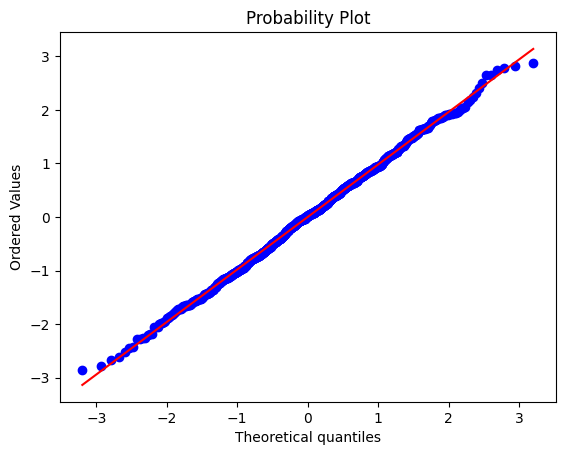

In [7]:
stats.probplot(normal_dist, dist='norm', plot=pylab)
pylab.show()

Boxplot

In [8]:
fig02 = go.Figure()
fig02.add_trace(go.Box(y=normal_dist, boxpoints='all', boxmean='sd', name='<b>Normal distribution', marker_color = 'blue'))
fig02.update_layout(width=400, height=400, template = 'simple_white',
                    paper_bgcolor="#f7f8fa", margin=dict(l=20, r=20, t=20, b=20),
                    showlegend=False)

In [9]:
print(np.quantile(normal_dist,.25))
print(np.percentile(normal_dist,25))

-0.7102216215806376
-0.7102216215806376


In [10]:
#Bibliotecas pandas estatistica.
df_normal_distrib = pd.DataFrame(normal_dist)
df_normal_distrib.describe()

,0
count,1000.000000
mean,0.001707
std,0.979604
min,-2.866266
25%,-0.710222
50%,0.023944
75%,0.651647
max,2.879035


# Assimetria

<img src="https://www.biologyforlife.com/uploads/2/2/3/9/22392738/c101b0da6ea1a0dab31f80d9963b0368_orig.png" width="800" align="left"/>

In [11]:
stats.skew(normal_dist)

0.013535659786954618

# **Medidas de dispersão (amplitude, desvios padrão e médio, coeficiente de variação e intervalo de confiança)**

In [12]:
amplitude = normal_dist.max() - normal_dist.min()
amplitude

5.74530113288316

Desvio padrão


O desvio padrão é uma medida que indica a dispersão dos dados dentro de uma amostra com relação à média. Assim, quando se calcula o desvio padrão juntamente com a média de diferentes grupos, obtém-se mais informações para avaliar e diferenciar seus comportamentos.


Fonte: https://statplace.com.br/blog/desvio-padrao-e-erro-padrao/

In [13]:
# Desvio padrão da amostra (população degrees of freedom = False)
# Sharpe ratio, bandas de bollinger

desvio_padrao = np.std(normal_dist, ddof = True)
desvio_padrao

0.9796038897827954

In [14]:
# Coeficiente de variação
# Interessante para comparações e avaliar a consistência (ex., pagamento de dividendos)

normal_dist.std(ddof = True)/normal_dist.mean()*100

57399.99104184921

In [15]:
# Erro padrão da média

stats.stats.sem(normal_dist)

C:\Users\akira\AppData\Local\Temp\ipykernel_6608\2554150148.py:3: DeprecationWarning:

Please import `sem` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.



0.030977794964741814

In [16]:
# Intervalo de confiança 95%
# Probabilidade de 95% da média real estar nesse intervalo

IC_95 = stats.t.interval(confidence=0.95, df=len(normal_dist)-1, loc=np.mean(normal_dist), scale=stats.sem(normal_dist))
IC_95

(-0.05908238418177415, 0.06249563868583352)

# Estudo de Caso

Importando as bibliotecas

In [17]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import sweetviz as sv 
import numpy as np
import pylab

### **2.1.2. Checando as medidas de posição e dispersão no dados do MF**

Vamos verificar na prática como essas métricas se comportam em dados reais

Estudos de caso:

1. Preços MGLU3

2. Preço e retornos IBOV

3. Dividendos em PETR4

4. Arbitragem em ações

Preços MGLU3

Extração pode ser feita de duas maneiras

In [18]:
mglu3_close = yf.download('MGLU3.SA', period = 'max')['Adj Close']

[*********************100%%**********************]  1 of 1 completed


In [19]:
mglu3_close.head()

Date
2011-05-02    0.201159
2011-05-03    0.199325
2011-05-04    0.201526
2011-05-05    0.200303
2011-05-06    0.198836
Name: Adj Close, dtype: float64

Fazendo um histograma

In [20]:
go.Histogram(x=mglu3_close)

Histogram({
    'x': array([ 0.20115888,  0.19932477,  0.20152579, ..., 14.69999981,
          14.19999981, 13.19999981])
})

In [21]:
fig01 = make_subplots(rows = 1, cols = 2)

fig01.add_trace(go.Histogram(x=mglu3_close),row=1,col=1)
fig01.add_vline(x=np.mean(mglu3_close), line_width=3,  line_color="red", row=1,col=1)
fig01.add_vline(x=np.median(mglu3_close), line_width=3, line_dash="dash", line_color="red",row=1,col=1)


fig01.add_trace(go.Box(y=mglu3_close, boxpoints='all', boxmean='sd'),row=1,col=2)

fig01.update_layout(width=800, height=400, template = 'simple_white', 
                    paper_bgcolor="#f7f8fa", margin=dict(l=20, r=20, t=20, b=20),
                    showlegend=True)



O preço não possui uma distribuição normal. Verifique acima em quais zonas o preço se concentrou ao longo do tempo.

# Preço e retornos IBOV

In [22]:
ibov = yf.download('^BVSP', start= '2000-01-1')['Close']

[*********************100%%**********************]  1 of 1 completed


In [23]:
ibov.head()

Date
2000-01-03    16930.0
2000-01-04    15851.0
2000-01-05    16245.0
2000-01-06    16107.0
2000-01-07    16309.0
Name: Close, dtype: float64

Fazendo o Histograma

In [24]:
fig02 = px.histogram(ibov, color_discrete_sequence=['lightseagreen'])

fig02.add_vline(x=np.mean(ibov), line_width=3,  line_color="red")
fig02.add_vline(x=np.median(ibov), line_width=3, line_dash="dash", line_color="red")

fig02.update_layout(width=400, height=400, template = 'simple_white',
                    paper_bgcolor="#f7f8fa", margin=dict(l=20, r=20, t=20, b=20),
                    showlegend=False)

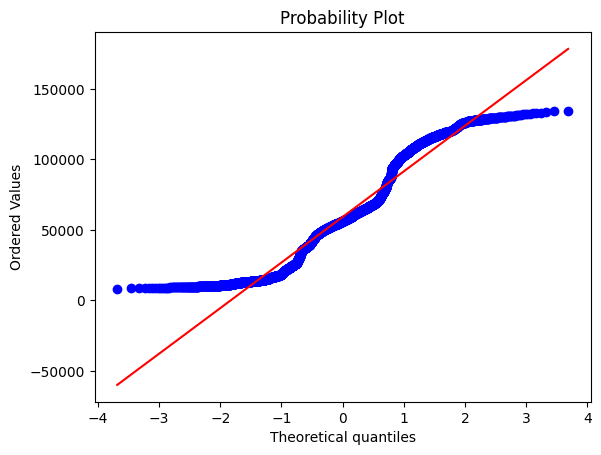

In [25]:
stats.probplot(ibov, dist="norm", plot=pylab)
pylab.show()

O resultado mostra que estamos muito longe de ter uma distribuição normal.

Veja a diferença quando modelamos os dados de retornos.

In [26]:
retornos_ibov = ibov.pct_change()

In [27]:
retornos_ibov.dropna(inplace=True)

In [28]:
np.mean(retornos_ibov)

0.00048180436242430244

In [29]:
fig03 = px.histogram(retornos_ibov, color_discrete_sequence=['lightseagreen'])

fig03.add_vline(x=np.mean(retornos_ibov), line_width=3,  line_color="red")
fig03.add_vline(x=np.median(retornos_ibov), line_width=3, line_dash="dash", line_color="red")

fig03.update_layout(width=400, height=400, template = 'simple_white',
                    paper_bgcolor="#f7f8fa", margin=dict(l=20, r=20, t=20, b=20),
                    showlegend=False)

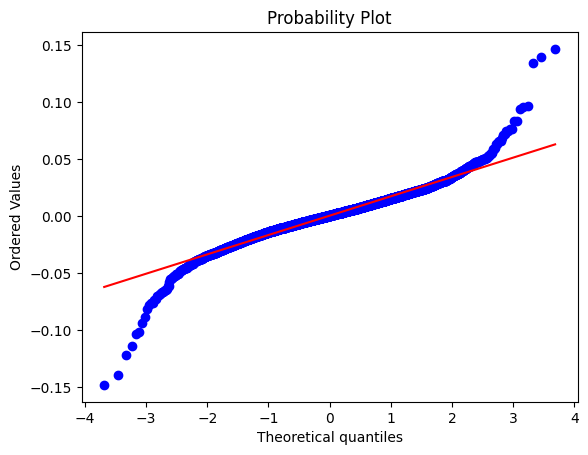

In [30]:
stats.probplot(retornos_ibov, dist="norm", plot=pylab)
pylab.show()

Assimetria e Curtose

In [31]:
stats.skew(retornos_ibov)

-0.12053111570524225

In [32]:
stats.kurtosis(retornos_ibov, fisher=True)

6.392564988698275

# Dividendos em PETR4

In [33]:
caminho_arquivo = r'C:/Users/akira/Python/Python_Mercado_Financeiro-PMF/Arquivos_Aula/Mod04/dividendos_petr4.csv.csv'

os.chdir(os.path.dirname(caminho_arquivo))

In [34]:
dividendos_petro = pd.read_csv('dividendos_petr4.csv')

In [35]:
dividendos_petro.tail()

,Date,Close,Dividends
5797,2023-01-27 03:00:00+00:00,25.620001,0.0
5798,2023-01-30 03:00:00+00:00,25.750000,0.0
5799,2023-01-31 03:00:00+00:00,26.070000,0.0
5800,2023-02-01 03:00:00+00:00,25.709999,0.0
5801,2023-02-02 03:00:00+00:00,24.520000,0.0


In [36]:
dividendos_petro4['soma_dividendos'] = dividendos_petro.Dividends.rolling('365D').sum()

ValueError: window must be an integer 0 or greater

# **3. Teste de Hipótese, p-valor e magnitude**
## *Estatística inferencial*
A estatística é uma **ciência sobre a incerteza**: probabilidade de um fenômeno ocorrer, desde que satisfeitas um conjunto de condições teóricas

Fenômeno/observação comumente estão enviesados


Baseado no nosso passado e experiências prévias, tendemos a chegar a conclusões distorcidas.

Na estatística inferencial, fazemos:

* Inferir sobre uma variável da população com base nos dados das amostras (repetições) - é muito difícil estudar a população inteira

* Generalizar uma observação a partir de probabilidades

Os **testes de hipótese** são amplamente utilizados em basicamente todas as áreas da ciência, incluindo a medicina, psicologia, finanças, marketing, entre outras, para testar teorias, avaliar o impacto de intervenções ou mudanças e fazer previsões.

Elas objetivam fornecer um método que permita verificar se os dados amostrais trazem evidências que apóiam ou não uma hipótese formulada.

São complementares aos mais variados testes estatísticos, desde os mais simples como test T, Anova, até os mais complexos, como modelos lineares mistos, logísticos...

<img src="https://editor.analyticsvidhya.com/uploads/52940cover.jpg" width="500" align="left"/>







O processo do teste de hipótese envolve duas hipóteses: a hipótese nula (H0), que é a afirmação a ser testada, e a hipótese alternativa (Ha), que é a afirmação oposta à hipótese nula.

Para realizar o teste, é escolhido um nível de significância (geralmente 5% ou 1%) que define o limite para a rejeição da hipótese nula. A partir da amostra, é calculado um valor chamado de estatística de teste, que é comparado a um valor crítico obtido a partir de uma tabela ou calculado através de métodos estatísticos.

---
**Vejamos na prática como funcionam os testes de hipótese?**

*Exemplo: Quero saber se as médias dos retornos do IBOV diferem entre os meses do ano*

**1° passo: determinar as hipóteses nula e alternativa**

* Hipótese H0 (nula): As médias dos retornos do IBOV <u>não diferem</u> entre os meses do ano, ou seja, são iguais estatisticamente
* Hipótese H1 (alternativa): As médias <u>diferem</u>, são diferentes significativamente

**2° passo: definir o nível de significância de teste**

<img src="https://miro.medium.com/max/1400/1*BwL6FDQ2B3QDKAwmcEVDSg.png" width="500" align="left"/>


**3° passo: executar o teste (seja ele qual for), checar o "valor de p" para decidir qual hipótese foi corroborada**


Se a estatística do teste é menor que o valor crítico, a hipótese nula não é rejeitada, o que significa que não há evidência suficiente para afirmar que a hipótese alternativa é verdadeira.

Por outro lado, se a estatística de teste é maior que o valor crítico, a hipótese nula é rejeitada e concluímos que a hipótese alternativa é provável.

---
#### **Valor de p**

Vamos relembrar que no início do módulo que a estatística enxerga o mundo a partir de duas dimensões:

* Magnitude
* Probabilidade

O teste de hipótese vai se basear no p (probabilidade)


**p-valor**: associado ao nível de significância do teste. De forma pragmática, é uma medida que representa a probabilidade da hipótese nula ser verdadeira considerando o seu conjunto de dados.



> p = 0.05 indica que há uma chance em 1 em 20 de que a hipótese nula seja corroborada. Em outras palavras, 5% de chance de que a relação estudada (resultado do teste estatístico executado) seja devido ao acaso, e não devido a fatores que estão sendo estudados

O valor de "p" é um número entre 0 e 1 e é interpretado da seguinte forma:

* se o valor de p é menor que um nível de significância **pré-definido** (geralmente 0.05 ou 0.01), então a hipótese nula é rejeitada em favor da hipótese alternativa.

Por exemplo, se o valor de p for 0.03 e o nível de significância for 0.05, então a hipótese nula será rejeitada, o que significa que há evidências estatísticas para suportar a hipótese alternativa.
Quanto menor o valor de p, maior é a evidência contra a hipótese nula (**em termos de probabilidade, mas não de efeito**).

# **4. Comparação de médias entre grupos (Teste T e Anova)**

Envolvem a análise de dados quantitativos (variável resposta) e qualitativos (grupos)

Sem dúvida estão entre os testes mais utilizados na ciência de dados como um todo. Para dados de séries temporais acabam sendo menos utilizados, já que este tipo de dado viola uma das premissas principais que é a aleatoriedade e independência das observações.

### **4.1. Organizar um banco de dados para os testes**

In [39]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pytz
from scipy import stats
from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pylab
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.figure_factory as ff

Criamos um dicionário para armazenar os ativos e setores do IBOV (utilizamos os espaçamentos apenas para facilitar a visualização)

In [51]:
ativos_setor_IBOV = {"AZUL4" : "Bens_industriais", "CCRO3" : "Bens_industriais", "ECOR3" : "Bens_industriais", 
                     "GOLL4" : "Bens_industriais", "RAIL3" : "Bens_industriais", "WEGE3" : "Bens_industriais",

                     "ALPA4" : "Consumo_ciclico", "ARZZ3" : "Consumo_ciclico", "CVCB3" : "Consumo_ciclico", "CYRE3" : "Consumo_ciclico",
                     "EZTC3" : "Consumo_ciclico", "LREN3" : "Consumo_ciclico", "MGLU3" : "Consumo_ciclico", "MRVE3" : "Consumo_ciclico",
                     "PETZ3" : "Consumo_ciclico", "SOMA3" : "Consumo_ciclico",

                     "ABEV3" : "Consumo_nao_ciclico", "ASAI3" : "Consumo_nao_ciclico", "BEEF3" : "Consumo_nao_ciclico",
                     "BRFS3" : "Consumo_nao_ciclico", "CRFB3" : "Consumo_nao_ciclico", "JBSS3" : "Consumo_nao_ciclico",
                     "MRFG3" : "Consumo_nao_ciclico", "NTCO3" : "Consumo_nao_ciclico", "PCAR3" : "Consumo_nao_ciclico",
                     "RAIZ4" : "Consumo_nao_ciclico", "SLCE3" : "Consumo_nao_ciclico", "SMTO3" : "Consumo_nao_ciclico",

                     "B3SA3" : "Financeiro_e_outros", "BBAS3" : "Financeiro_e_outros",
                     "BBDC3" : "Financeiro_e_outros", "BBDC4" : "Financeiro_e_outros", "BBSE3" : "Financeiro_e_outros",
                     "BPAC11" : "Financeiro_e_outros", "BPAN4" : "Financeiro_e_outros", "CIEL3" : "Financeiro_e_outros",
                     "IGTI11" : "Financeiro_e_outros", "ITSA4" : "Financeiro_e_outros", "ITUB4" : "Financeiro_e_outros",
                     "MULT3" : "Financeiro_e_outros", "SANB11" : "Financeiro_e_outros",

                     "BRAP4" : "Mats_basicos", "BRKM5" : "Mats_basicos", "CMIN3" : "Mats_basicos", "CSNA3" : "Mats_basicos", "DXCO3" : "Mats_basicos",
                     "GGBR4" : "Mats_basicos", "GOAU4" : "Mats_basicos", "KLBN11" : "Mats_basicos", "SUZB3" : "Mats_basicos", "USIM5" : "Mats_basicos",
                     "VALE3" : "Mats_basicos",

                     "CSAN3" : "Petroleo_gas_biocombustiveis", "PETR3" : "Petroleo_gas_biocombustiveis", "PETR4" : "Petroleo_gas_biocombustiveis",
                     "PRIO3" : "Petroleo_gas_biocombustiveis", "RRRP3" : "Petroleo_gas_biocombustiveis", "UGPA3" : "Petroleo_gas_biocombustiveis",
                     "VBBR3" : "Petroleo_gas_biocombustiveis",

                     "FLRY3" : "Saude", "HAPV3" : "Saude", "HYPE3" : "Saude", "QUAL3" : "Saude", "RADL3" : "Saude", "RDOR3" : "Saude",

                     "CMIG4" : "Utilidade_publica", "CPFE3" : "Utilidade_publica", "CPLE6" : "Utilidade_publica", "EGIE3" : "Utilidade_publica",
                     "ELET3" : "Utilidade_publica", "ELET6" : "Utilidade_publica", "ENBR3" : "Utilidade_publica", "ENEV3" : "Utilidade_publica",
                     "ENGI11" : "Utilidade_publica", "EQTL3" : "Utilidade_publica", "SBSP3" : "Utilidade_publica", "TAEE11" : "Utilidade_publica"}

In [52]:
list(ativos_setor_IBOV.keys())

['AZUL4',
 'CCRO3',
 'ECOR3',
 'GOLL4',
 'RAIL3',
 'WEGE3',
 'ALPA4',
 'ARZZ3',
 'CVCB3',
 'CYRE3',
 'EZTC3',
 'LREN3',
 'MGLU3',
 'MRVE3',
 'PETZ3',
 'SOMA3',
 'ABEV3',
 'ASAI3',
 'BEEF3',
 'BRFS3',
 'CRFB3',
 'JBSS3',
 'MRFG3',
 'NTCO3',
 'PCAR3',
 'RAIZ4',
 'SLCE3',
 'SMTO3',
 'B3SA3',
 'BBAS3',
 'BBDC3',
 'BBDC4',
 'BBSE3',
 'BPAC11',
 'BPAN4',
 'CIEL3',
 'IGTI11',
 'ITSA4',
 'ITUB4',
 'MULT3',
 'SANB11',
 'BRAP4',
 'BRKM5',
 'CMIN3',
 'CSNA3',
 'DXCO3',
 'GGBR4',
 'GOAU4',
 'KLBN11',
 'SUZB3',
 'USIM5',
 'VALE3',
 'CSAN3',
 'PETR3',
 'PETR4',
 'PRIO3',
 'RRRP3',
 'UGPA3',
 'VBBR3',
 'FLRY3',
 'HAPV3',
 'HYPE3',
 'QUAL3',
 'RADL3',
 'RDOR3',
 'CMIG4',
 'CPFE3',
 'CPLE6',
 'EGIE3',
 'ELET3',
 'ELET6',
 'ENBR3',
 'ENEV3',
 'ENGI11',
 'EQTL3',
 'SBSP3',
 'TAEE11']

In [53]:
#Adicinal o "S.A" necessário ao Yahoo
lista_ativos = list(ativos_setor_IBOV.keys())
lista_ativos_yf =[lista_ativos + '.SA' for lista_ativos in lista_ativos]
lista_ativos_yf[0:5]

['AZUL4.SA', 'CCRO3.SA', 'ECOR3.SA', 'GOLL4.SA', 'RAIL3.SA']

In [54]:
# Buscar os dados de 2023 (precisaremos de Dividends e Close)

df_dados = yf.download(lista_ativos_yf, start='2023-01-01', end='2023-12-31', actions=True)[['Close', 'Dividends']]

[*********************100%%**********************]  77 of 77 completed

1 Failed download:
['ENBR3.SA']: Exception('%ticker%: No timezone found, symbol may be delisted')


In [55]:
# Observe que os ativos são automaticamente classificados por ordem alfabética

df_dados

Price         Close                                                     \
Ticker     ABEV3.SA ALPA4.SA   ARZZ3.SA   ASAI3.SA   AZUL4.SA B3SA3.SA   
Date                                                                     
2023-01-02    14.19    14.33  74.120003  18.990000  10.300000    12.25   
2023-01-03    14.17    13.40  71.809998  18.610001  10.160000    11.84   
2023-01-04    14.25    13.49  73.459999  19.080000  10.560000    11.93   
2023-01-05    14.29    13.86  74.339996  18.980000  11.550000    12.30   
2023-01-06    14.32    13.87  75.800003  19.040001  11.840000    12.59   
...             ...      ...        ...        ...        ...      ...   
2023-12-21    13.70     9.13  66.160004  13.240000  16.410000    14.49   
2023-12-22    13.71     9.50  66.650002  13.410000  16.299999    14.51   
2023-12-26    13.77     9.75  66.400002  13.370000  16.260000    14.66   
2023-12-27    13.84    10.12  66.629997  13.480000  16.570000    14.58   
2023-12-28    13.73    10.12  64.529999  13.530000  16.010000    14.55   

Price                                                 ... Dividends           \
Ticker       BBAS3.SA BBDC3.SA   BBDC4.SA   BBSE3.SA  ...  SLCE3.SA SMTO3.SA   
Date                                                  ...                      
2023-01-02  16.629999    13.19  14.750000  33.389999  ...  0.000000      0.0   
2023-01-03  16.320000    12.55  14.000000  32.349998  ...  0.000000      0.0   
2023-01-04  16.530001    12.66  14.040000  32.509998  ...  0.000000      0.0   
2023-01-05  17.285000    13.07  14.650000  32.580002  ...  0.000000      0.0   
2023-01-06  17.525000    13.42  15.060000  33.529999  ...  0.000000      0.0   
...               ...      ...        ...        ...  ...       ...      ...   
2023-12-21  27.145000    15.46  17.270000  33.150002  ...  0.000000      0.0   
2023-12-22  27.219999    15.05  16.830000  33.360001  ...  0.000000      0.0   
2023-12-26  27.469999    15.11  16.879999  33.610001  ...  0.000000      0.0   
2023-12-27  27.430000    15.22  16.980000  33.380001  ...  0.000000      0.0   
2023-12-28  27.695000    15.28  17.090000  33.650002  ...  0.054527      0.0   

Price                                                                        \
Ticker     SOMA3.SA SUZB3.SA TAEE11.SA UGPA3.SA USIM5.SA VALE3.SA  VBBR3.SA   
Date                                                                          
2023-01-02      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-01-03      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-01-04      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-01-05      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-01-06      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
...             ...      ...       ...      ...      ...      ...       ...   
2023-12-21      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-12-22      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-12-26      0.0      0.0       0.0      0.0      0.0      0.0  0.403621   
2023-12-27      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   
2023-12-28      0.0      0.0       0.0      0.0      0.0      0.0  0.000000   

Price                
Ticker     WEGE3.SA  
Date                 
2023-01-02      0.0  
2023-01-03      0.0  
2023-01-04      0.0  
2023-01-05      0.0  
2023-01-06      0.0  
...             ...  
2023-12-21      0.0  
2023-12-22      0.0  
2023-12-26      0.0  
2023-12-27      0.0  
2023-12-28      0.0  

[248 rows x 153 columns]

In [58]:
# E do preço de fechamento do último dia do ano

close_ativo = df_dados['Close'].iloc[-1]
close_ativo

Ticker
ABEV3.SA    13.730000
ALPA4.SA    10.120000
ARZZ3.SA    64.529999
ASAI3.SA    13.530000
AZUL4.SA    16.010000
              ...    
UGPA3.SA    26.510000
USIM5.SA     9.290000
VALE3.SA    77.199997
VBBR3.SA    22.760000
WEGE3.SA    36.910000
Name: 2023-12-28 00:00:00, Length: 77, dtype: float64

In [56]:
# Precisaremos da soma dos dividendos pagos no ano para cada ativo

soma_dividendos = df_dados['Dividends'].sum()
soma_dividendos

Ticker
ABEV3.SA    0.730200
ALPA4.SA    0.000000
ARZZ3.SA    1.932467
ASAI3.SA    0.050019
AZUL4.SA    0.000000
              ...   
UGPA3.SA    0.350000
USIM5.SA    0.328767
VALE3.SA    4.511889
VBBR3.SA    0.832716
WEGE3.SA    0.614800
Length: 76, dtype: float64

In [59]:
# Tabela com os Dividend Yield (%) anuais de cada ativo
# Ordenar para concatenar com o df dos setores

tabela_DY_2023 = pd.DataFrame(soma_dividendos/close_ativo*100, columns=['DY_%'])
tabela_DY_2023.sort_index()

,DY_%
Ticker,
ABEV3.SA,5.318281
ALPA4.SA,0.000000
ARZZ3.SA,2.994680
ASAI3.SA,0.369690
AZUL4.SA,0.000000
...,...
UGPA3.SA,1.320256
USIM5.SA,3.538934
VALE3.SA,5.844416
